In [ ]:
# Install any missing libraries
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet
print('Libraries ready!')

Libraries ready!


In [ ]:
# pandas: for loading and working with tabular data (like Excel)
import pandas as pd

# numpy: for mathematical operations on numbers
import numpy as np

# matplotlib and seaborn: for creating charts and graphs
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sklearn Pipeline Tools ---
# Pipeline: chains multiple steps together into one object
from sklearn.pipeline import Pipeline

# ColumnTransformer: applies different preprocessing to different columns
# Example: scale numbers, encode text separately
from sklearn.compose import ColumnTransformer

# --- Preprocessing Tools ---
# StandardScaler: converts numbers to same scale (mean=0, std=1)
# Example: age=25 and salary=50000 become comparable numbers
from sklearn.preprocessing import StandardScaler

# OneHotEncoder: converts text categories to numbers
# Example: 'Male'/'Female' → [1,0] / [0,1]
from sklearn.preprocessing import OneHotEncoder

# SimpleImputer: fills in missing values automatically
# Example: if age is missing, fill with average age
from sklearn.impute import SimpleImputer

# --- ML Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# --- Model Evaluation ---
# train_test_split: splits data into training and testing portions
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Metrics to measure how good our model is
from sklearn.metrics import (
    accuracy_score,        # % of correct predictions
    classification_report, # precision, recall, F1 per class
    confusion_matrix,      # table of correct/incorrect predictions
    roc_auc_score,         # area under ROC curve (higher = better)
    roc_curve              # for plotting ROC curve
)

# joblib: saves our trained pipeline to a file so we can reuse it later
import joblib

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


In [ ]:
# This code opens a file upload dialog in Google Colab
# Click "Choose Files" and select your downloaded CSV file
from google.colab import files
uploaded = files.upload()
print("File uploaded successfully!")

# Load the CSV file into a pandas DataFrame
# A DataFrame is like an Excel spreadsheet in Python
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Show the shape: (rows, columns)
print('Dataset Shape:', df.shape)

# Show first 5 rows to understand the data
print('First 5 rows:')
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv
File uploaded successfully!
Dataset Shape: (7043, 21)
First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Check column names and data types
# 'object' means text, 'int64'/'float64' means number
print('Column Info:')
print(df.dtypes)
print()

# Check for missing values in each column
# isnull() marks missing cells as True
# sum() counts how many True values (missing) per column
print('Missing Values:')
print(df.isnull().sum())

Column Info:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling

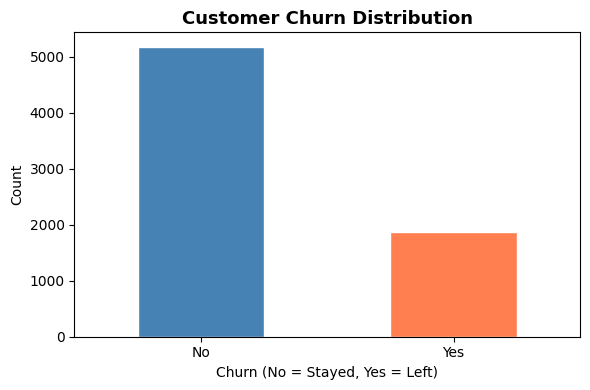

Churn Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
# ---- Visualize Churn Distribution ----
# How many customers stayed vs left?

plt.figure(figsize=(6, 4))

# value_counts() counts how many 'Yes' and 'No' in Churn column
df['Churn'].value_counts().plot(
    kind='bar',           # bar chart
    color=['steelblue', 'coral'],
    edgecolor='white'
)
plt.title('Customer Churn Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Churn (No = Stayed, Yes = Left)')
plt.ylabel('Count')
plt.xticks(rotation=0)   # keep labels horizontal
plt.tight_layout()
plt.show()

# Print exact numbers
print('Churn Counts:')
print(df['Churn'].value_counts())
print()
print('Churn Percentage:')
print(df['Churn'].value_counts(normalize=True) * 100)  # normalize=True gives percentages

In [ ]:
# Step 5a: Drop customerID column
# customerID is just a unique number for each customer
# It has NO useful information for prediction — so we remove it
df = df.drop('customerID', axis=1)  # axis=1 means drop a column (axis=0 drops a row)

# Step 5b: Fix TotalCharges column
# TotalCharges should be a number but it's stored as text
# We convert it to number using pd.to_numeric()
# errors='coerce' means: if something can't be converted, make it NaN (missing)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 5c: Drop rows where TotalCharges is still missing
# dropna() removes rows with any missing values
df = df.dropna()

# Step 5d: Convert target column 'Churn' from Yes/No text to 1/0 numbers
# ML models need numbers, not text
# map() replaces values: 'Yes' → 1, 'No' → 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('After cleaning:')
print('Shape:', df.shape)
print('Missing values:', df.isnull().sum().sum())  # should be 0
print('Churn values:', df['Churn'].unique())        # should be [0, 1]

After cleaning:
Shape: (7032, 20)
Missing values: 0
Churn values: [0 1]


In [ ]:
# Step 5e: Separate features (X) and target (y)
# X = all columns EXCEPT Churn (these are our inputs)
# y = only the Churn column (this is what we want to predict)

X = df.drop('Churn', axis=1)   # remove Churn column from features
y = df['Churn']                 # keep only Churn as the target

print('Features shape (X):', X.shape)
print('Target shape (y):', y.shape)

# Step 5f: Identify which columns are numbers and which are text
# We need to treat them differently in the pipeline

# select_dtypes selects columns by data type
# 'number' = all numeric columns (int, float)
numerical_cols = X.select_dtypes(include='number').columns.tolist()

# 'object' = all text/category columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print()
print('Numerical columns:', numerical_cols)
print()
print('Categorical columns:', categorical_cols)

Features shape (X): (7032, 19)
Target shape (y): (7032,)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
# Step 5g: Split data into training and testing sets
# We train the model on 80% of data
# We TEST it on the remaining 20% (data it has never seen)
# This tells us how well it works on NEW customers

X_train, X_test, y_train, y_test = train_test_split(
    X,              # features
    y,              # target
    test_size=0.2,  # 20% goes to test set
    random_state=42 # fixed seed = same split every time you run
)

print('Training samples:', X_train.shape[0])
print('Testing samples: ', X_test.shape[0])

Training samples: 5625
Testing samples:  1407


In [ ]:
numerical_pipeline = Pipeline(steps=[

    # Step 1: Fill missing numbers with the MEDIAN value of that column
    # strategy='median' means: use the middle value (robust to outliers)
    ('imputer', SimpleImputer(strategy='median')),

    # Step 2: Scale all numbers to the same range
    # StandardScaler makes mean=0, std=1
    # This prevents big numbers (like charges=5000) from dominating small ones (like tenure=2)
    ('scaler', StandardScaler())
])


categorical_pipeline = Pipeline(steps=[

    # Step 1: Fill missing text values with the most frequent value
    # strategy='most_frequent' = use whichever value appears most
    ('imputer', SimpleImputer(strategy='most_frequent')),

    # Step 2: Convert text categories to numbers using One-Hot Encoding
    # Example: Gender = ['Male', 'Female'] becomes two columns:
    #   Gender_Male = [1, 0, 1, 0]
    #   Gender_Female = [0, 1, 0, 1]
    # handle_unknown='ignore' = if a new unseen category appears, just ignore it
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(transformers=[

    # ('name', which_pipeline, which_columns)
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print('Pipeline structure built successfully!')
print()
print('Numerical pipeline steps:', [s[0] for s in numerical_pipeline.steps])
print('Categorical pipeline steps:', [s[0] for s in categorical_pipeline.steps])

Pipeline structure built successfully!

Numerical pipeline steps: ['imputer', 'scaler']
Categorical pipeline steps: ['imputer', 'encoder']


In [ ]:
# Build complete pipeline: preprocessor + Logistic Regression model
# This single object does EVERYTHING: clean, scale, encode, then train

lr_pipeline = Pipeline(steps=[
    # Step 1: all the preprocessing we defined above
    ('preprocessor', preprocessor),

    # Step 2: the actual ML model
    # max_iter=1000 = allow 1000 iterations to find best solution
    # random_state=42 = reproducible results
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# .fit() trains the ENTIRE pipeline on training data
# It runs: impute → scale → encode → train model, all in one go!
lr_pipeline.fit(X_train, y_train)

# .predict() makes predictions on test data
# The test data also goes through all preprocessing steps automatically
lr_pred = lr_pipeline.predict(X_test)

# Calculate accuracy: % of correct predictions
lr_acc = accuracy_score(y_test, lr_pred)
print(f'Logistic Regression Accuracy: {lr_acc * 100:.2f}%')

Logistic Regression Accuracy: 78.75%


In [ ]:
# Random Forest is an ensemble model — it builds many decision trees and combines their predictions (like asking 100 experts and voting)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),

    # n_estimators=100 = build 100 decision trees
    # random_state=42 = reproducible results
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print(f'Random Forest Accuracy: {rf_acc * 100:.2f}%')

Random Forest Accuracy: 77.75%


In [ ]:
# Define which settings (hyperparameters) to try. It automatically tries many combinations of settings and finds the BEST one.

param_grid = {
    # Try different numbers of trees: 50 or 100
    'model__n_estimators': [50, 100],

    # Try different tree depths: 5 or 10 levels deep
    # Deeper = more complex model but might overfit
    'model__max_depth': [5, 10],

    # Try different minimum samples needed to split a node
    'model__min_samples_split': [2, 5]
}

# GridSearchCV tries ALL combinations:
# 2 x 2 x 2 = 8 combinations
# cv=3 means: test each combination 3 times (3-fold cross validation)
# scoring='accuracy' means: pick the combo with highest accuracy
# n_jobs=-1 means: use all CPU cores to speed up

print('Starting GridSearchCV...')
print('This tries 8 combinations x 3 folds = 24 training runs')
print('Please wait...')

grid_search = GridSearchCV(
    rf_pipeline,         # our Random Forest pipeline
    param_grid,          # combinations to try
    cv=3,                # 3-fold cross validation
    scoring='accuracy',  # optimize for accuracy
    n_jobs=-1,           # use all CPU cores
    verbose=1            # show basic progress
)

grid_search.fit(X_train, y_train)

print()
print('Best settings found:', grid_search.best_params_)
print('Best cross-validation accuracy:', f"{grid_search.best_score_ * 100:.2f}%")

Starting GridSearchCV...
This tries 8 combinations x 3 folds = 24 training runs
Please wait...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best settings found: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best cross-validation accuracy: 80.44%


In [ ]:
# joblib saves the ENTIRE trained pipeline to a file
# This includes: imputer + scaler + encoder + trained model
# Later, you can load this file and make predictions on NEW data
# WITHOUT retraining! This is called 'model deployment'

# Save the best model to a file named 'churn_pipeline.pkl'
# .pkl is a Python format for saving objects
joblib.dump(best_model, 'churn_pipeline.pkl')
print('Pipeline saved to churn_pipeline.pkl!')

# ---- How to load and use it later ----
print()
print('To use later:')
print('  loaded_pipeline = joblib.load("churn_pipeline.pkl")')
print('  prediction = loaded_pipeline.predict(new_customer_data)')

# Verify: load it back and make a test prediction
loaded_pipeline = joblib.load('churn_pipeline.pkl')
test_pred = loaded_pipeline.predict(X_test[:5])  # predict first 5 test samples
print()
print('Test predictions from loaded pipeline:', test_pred)
print('Actual values:                        ', y_test[:5].values)
print()
print('Pipeline works correctly after loading!')

Pipeline saved to churn_pipeline.pkl!

To use later:
  loaded_pipeline = joblib.load("churn_pipeline.pkl")
  prediction = loaded_pipeline.predict(new_customer_data)

Test predictions from loaded pipeline: [0 0 1 0 0]
Actual values:                         [0 0 1 0 0]

Pipeline works correctly after loading!
